# 04 — Evaluate Similarity: OD Model vs SD Model (M Repetitions)

Quantify how closely the CART-synthesised regression model reproduces the original regression model across **M** repetitions using:

1. **Euclidean distance** between estimated coefficient vectors  
   $$d(\hat{\beta}_{OD}, \hat{\beta}_{SD}) = \sqrt{\sum_{j=0}^{p} (\hat{\beta}_{OD,j} - \hat{\beta}_{SD,j})^2}$$

2. **Prediction drift** — MSE and MAE between predictions of the two models on a fresh, independent test set.

All metrics are computed per repetition and then visualised as distributions to reveal variability and robustness of the synthesis process.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import json
import os
import glob
import pickle
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.lines import Line2D

from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.family": "sans-serif",
})

In [2]:
# ── Load Configuration ──────────────────────────────────────────────────────
config_path = os.path.join("..", "config", "config.json")
with open(config_path, "r") as f:
    config = json.load(f)

N_test    = config["simulation"]["N_test"]
p         = config["simulation"]["p"]
sigma_2   = config["simulation"]["sigma_2"]
test_seed = config["simulation"]["test_seed"]
M         = config["simulation"]["M"]
rho_vals  = config["parameters"]["rho"]
beta      = np.array(config["parameters"]["beta"])  # length p+1

print(f"Test-set config: N_test={N_test}, p={p}, sigma_2={sigma_2}, seed={test_seed}")
print(f"M = {M} repetitions, Rho values: {rho_vals}")
print(f"True beta:  {beta}")

Test-set config: N_test=10000, p=10, sigma_2=1, seed=123
M = 50 repetitions, Rho values: [0.0, 0.3, 0.5]
True beta:  [1 1 1 1 1 1 1 1 1 1 1]


In [3]:
# ── Helper: generate an independent test dataset ───────────────────────────
def make_sigma(p, rho):
    """Equi-correlation covariance matrix (1 on diag, rho off-diag)."""
    Sigma = np.full((p, p), rho)
    np.fill_diagonal(Sigma, 1.0)
    return Sigma


def generate_test(N, p, rho, beta, sigma_2, seed=123):
    """Generate X ~ MVN(0, Sigma), y = Xβ + ε, return DataFrame."""
    rng = np.random.default_rng(seed)
    Sigma = make_sigma(p, rho)
    X = rng.multivariate_normal(mean=np.zeros(p), cov=Sigma, size=N)
    X_design = np.column_stack([np.ones(N), X])  # add intercept column
    epsilon = rng.normal(0, np.sqrt(sigma_2), size=N)
    y = X_design @ beta + epsilon

    df = pd.DataFrame(X, columns=[f"X{i+1}" for i in range(p)])
    df["y"] = y
    return df


# Pre-generate test sets for each rho (shared across all M reps)
test_sets = {}
for rho in rho_vals:
    test_sets[rho] = generate_test(N_test, p, rho, beta, sigma_2, seed=test_seed)
    print(f"Test set for ρ={rho}: {test_sets[rho].shape}")

Test set for ρ=0.0: (10000, 11)
Test set for ρ=0.3: (10000, 11)
Test set for ρ=0.5: (10000, 11)


In [4]:
# ── Discover saved model files ─────────────────────────────────────────────
model_dir  = os.path.join("..", "models")
result_dir = os.path.join("..", "results")
os.makedirs(result_dir, exist_ok=True)

model_files = sorted(glob.glob(os.path.join(model_dir, "models_*.pkl")))
assert len(model_files) > 0, f"No model files found in {model_dir}"

print(f"Found {len(model_files)} model pair(s) to evaluate.")

Found 150 model pair(s) to evaluate.


## Evaluate Each Scenario

In [5]:
# ── Evaluate each (rho, rep) model pair ─────────────────────────────────────
all_metrics = []

for mf in model_files:
    with open(mf, "rb") as f:
        bundle = pickle.load(f)

    lm_od    = bundle["lm_od"]
    lm_sd    = bundle["lm_sd"]
    scenario = bundle["scenario"]
    rho      = bundle.get("rho")
    rep      = bundle.get("rep")

    # Fallback parsing if keys missing
    if rho is None:
        rho = float(re.search(r"rho([\d.]+)", scenario).group(1))
    if rep is None:
        m = re.search(r"rep(\d+)", scenario)
        rep = int(m.group(1)) if m else 1

    # (a) Euclidean distance between coefficient vectors
    beta_od = np.concatenate([[lm_od.intercept_], lm_od.coef_])
    beta_sd = np.concatenate([[lm_sd.intercept_], lm_sd.coef_])
    eucl_dist = np.linalg.norm(beta_od - beta_sd)

    # (b) Max absolute coefficient difference
    max_abs_diff = np.max(np.abs(beta_od - beta_sd))

    # (c) Cosine similarity between coefficient vectors
    cos_sim = np.dot(beta_od, beta_sd) / (np.linalg.norm(beta_od) * np.linalg.norm(beta_sd))

    # (d) Prediction-based metrics on fresh test data
    test_data = test_sets[rho]
    X_test = test_data.drop(columns="y")

    pred_od = lm_od.predict(X_test)
    pred_sd = lm_sd.predict(X_test)

    mse_pred = mean_squared_error(pred_od, pred_sd)
    mae_pred = mean_absolute_error(pred_od, pred_sd)

    # (e) Correlation between OD and SD predictions
    pred_corr = np.corrcoef(pred_od, pred_sd)[0, 1]

    all_metrics.append({
        "scenario": scenario,
        "rho": rho,
        "rep": rep,
        "euclidean_dist": eucl_dist,
        "max_abs_coef_diff": max_abs_diff,
        "cosine_similarity": cos_sim,
        "prediction_mse": mse_pred,
        "prediction_mae": mae_pred,
        "prediction_corr": pred_corr,
    })

metrics_df = pd.DataFrame(all_metrics)
print(f"Evaluated {len(metrics_df)} model pairs. Shape: {metrics_df.shape}")

Evaluated 150 model pairs. Shape: (150, 9)


## Summary Table

In [6]:
# ── Summary table aggregated by rho ─────────────────────────────────────────
numeric_cols = ["euclidean_dist", "max_abs_coef_diff", "cosine_similarity",
                "prediction_mse", "prediction_mae", "prediction_corr"]

summary = (
    metrics_df
    .groupby("rho")[numeric_cols]
    .agg(["mean", "std", "median"])
    .round(6)
)
display(summary)

# Save full per-rep metrics
out_path = os.path.join(result_dir, "evaluation_metrics.csv")
metrics_df.to_csv(out_path, index=False)
print(f"\nFull metrics saved to: {out_path}")

euclidean_dist                     max_abs_coef_diff                      \
              mean       std    median              mean       std    median   
rho                                                                            
0.0       0.987349  0.029863  0.988678          0.391802  0.024927  0.390726   
0.3       0.379419  0.030116  0.378071          0.203871  0.030919  0.199843   
0.5       0.299965  0.040502  0.306985          0.177393  0.030607  0.178810   

    cosine_similarity                     prediction_mse                      \
                 mean       std    median           mean       std    median   
rho                                                                            
0.0          0.990013  0.001665  0.990059       0.952954  0.057688  0.953097   
0.3          0.996577  0.001166  0.996564       0.374701  0.036484  0.375228   
0.5          0.996702  0.001189  0.996711       0.185919  0.029331  0.186470   

    prediction_mae                     prediction_corr                      
              mean       std    median            mean       std    median  
rho                                                                         
0.0       0.777509  0.023545  0.779009        0.996718  0.001166  0.996812  
0.3       0.488440  0.024044  0.488933        0.999382  0.000254  0.999378  
0.5       0.342992  0.027028  0.344543        0.999684  0.000117  0.999681


Full metrics saved to: ../results/evaluation_metrics.csv


## Visualisations

Rich plots showing metric distributions across M repetitions for each correlation setting.

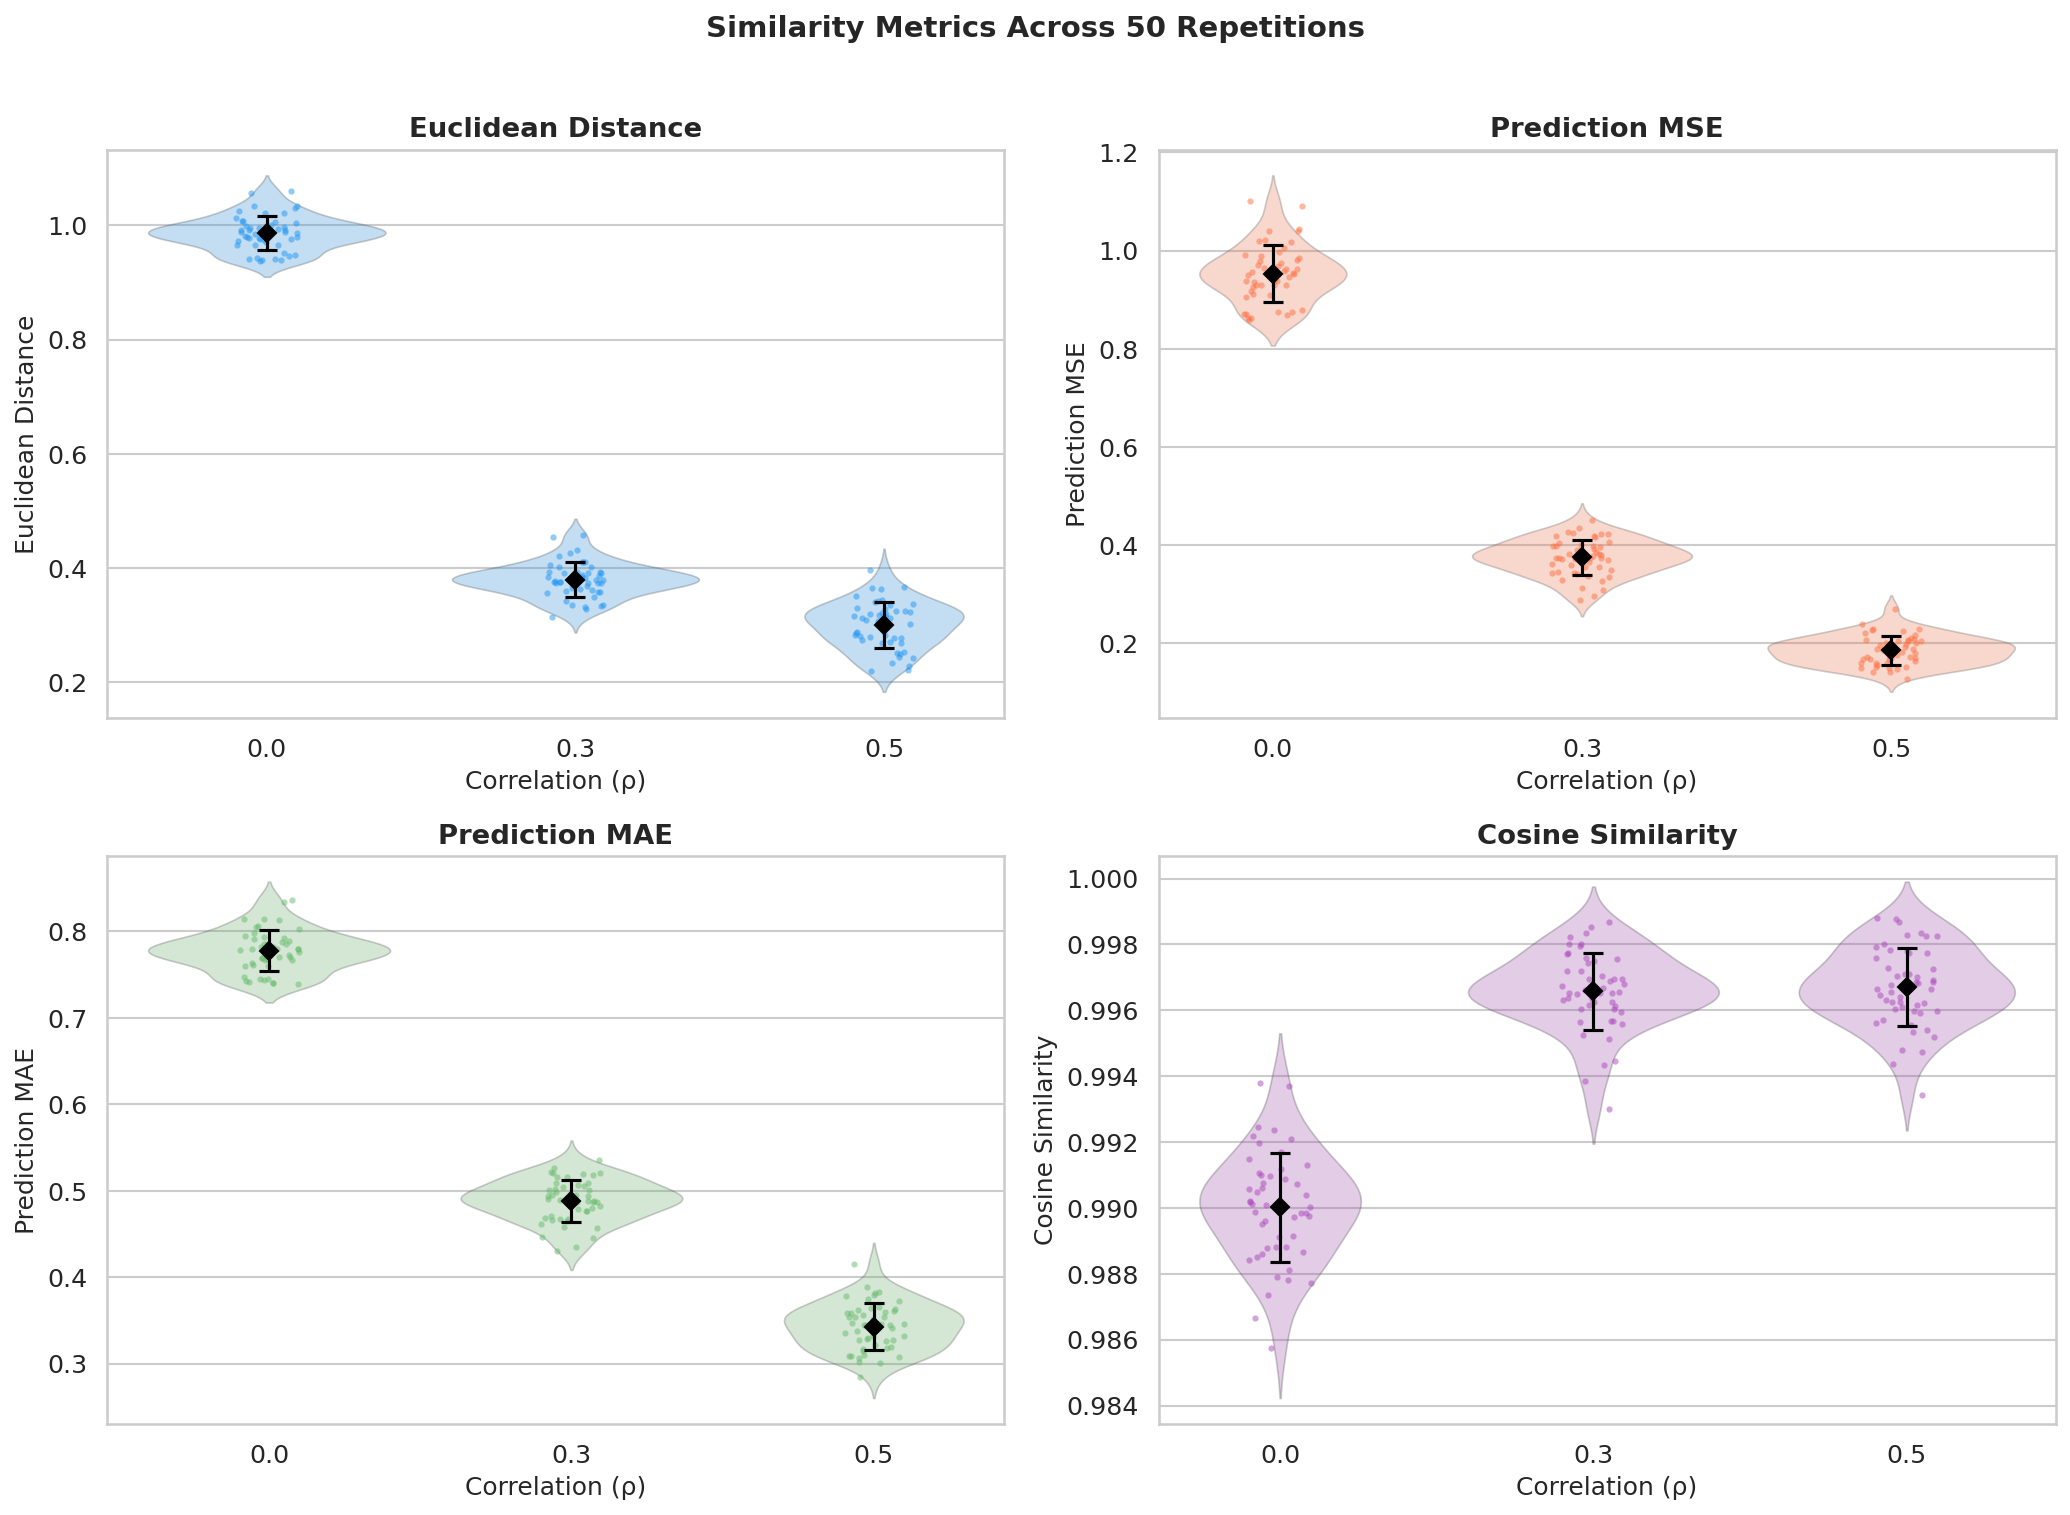

In [7]:
# ── Plot 1: Violin + Strip — Key Metrics by ρ ──────────────────────────────
metric_info = [
    ("euclidean_dist",    "Euclidean Distance",   "#2196F3"),
    ("prediction_mse",    "Prediction MSE",       "#FF7043"),
    ("prediction_mae",    "Prediction MAE",       "#66BB6A"),
    ("cosine_similarity", "Cosine Similarity",    "#AB47BC"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (col, title, color) in zip(axes, metric_info):
    sns.violinplot(
        data=metrics_df, x="rho", y=col,
        color=color, alpha=0.3, inner=None, ax=ax, linewidth=0.8,
    )
    sns.stripplot(
        data=metrics_df, x="rho", y=col,
        color=color, alpha=0.5, size=3, jitter=True, ax=ax,
    )
    # Overlay mean ± std error bars
    means = metrics_df.groupby("rho")[col].mean()
    stds  = metrics_df.groupby("rho")[col].std()
    x_pos = range(len(means))
    ax.errorbar(x_pos, means, yerr=stds, fmt="D", color="black",
                markersize=6, capsize=5, capthick=1.5, lw=1.5, zorder=5)

    ax.set_title(title)
    ax.set_xlabel("Correlation (ρ)")
    ax.set_ylabel(title)

plt.suptitle(f"Similarity Metrics Across {M} Repetitions", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_metrics_violin.png"), dpi=200, bbox_inches="tight")
plt.show()

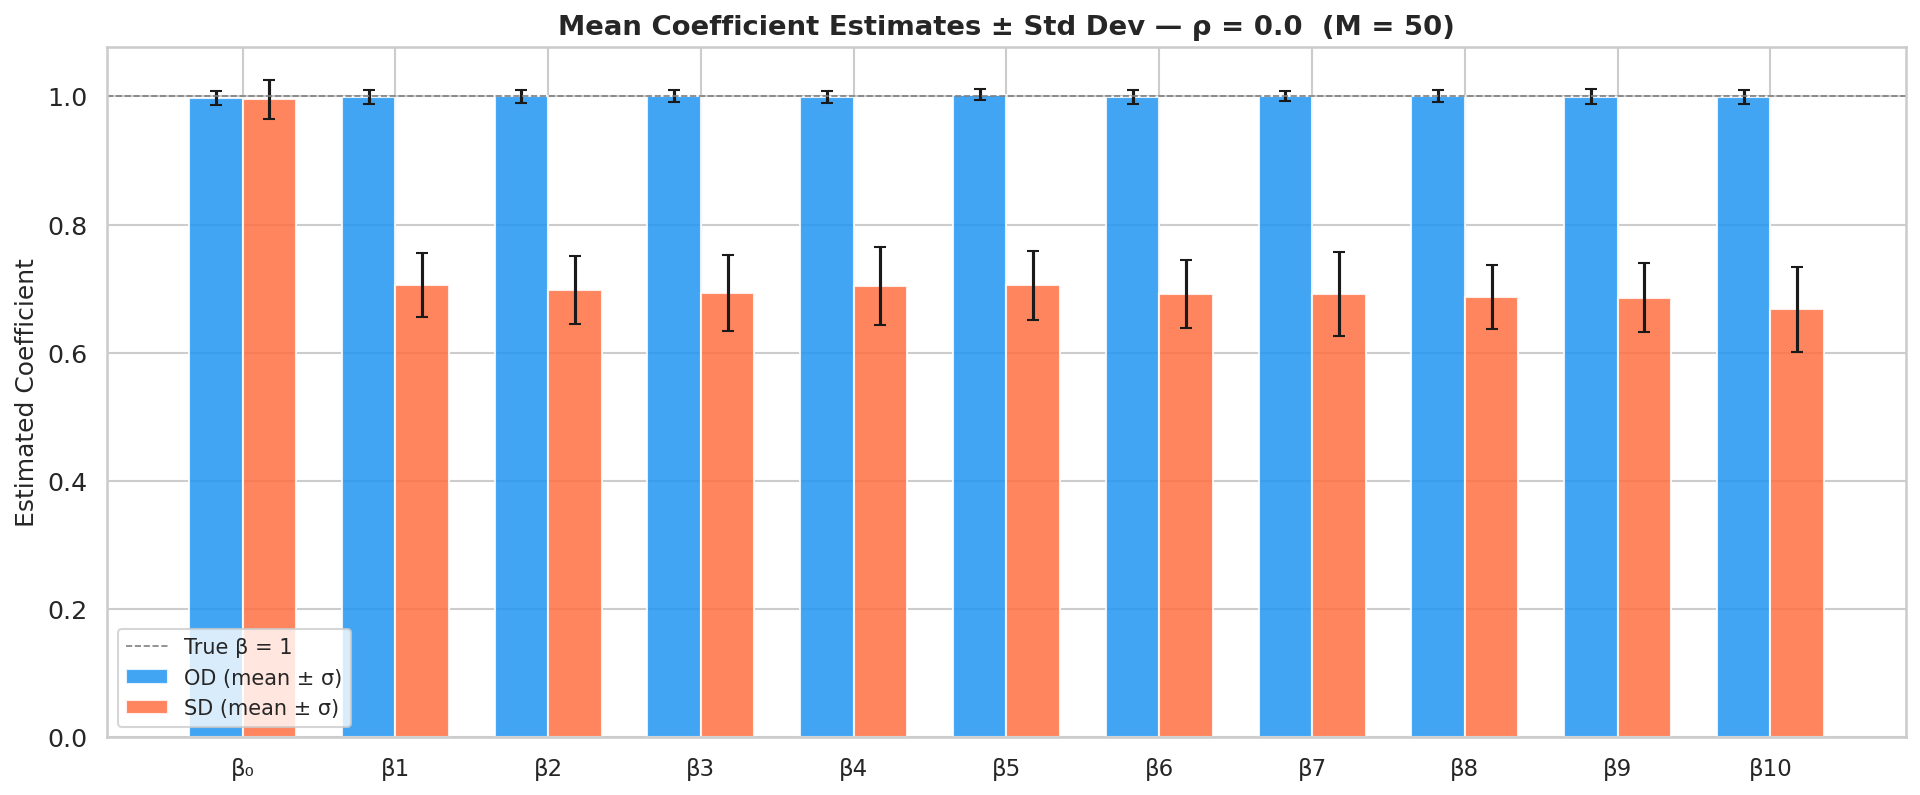

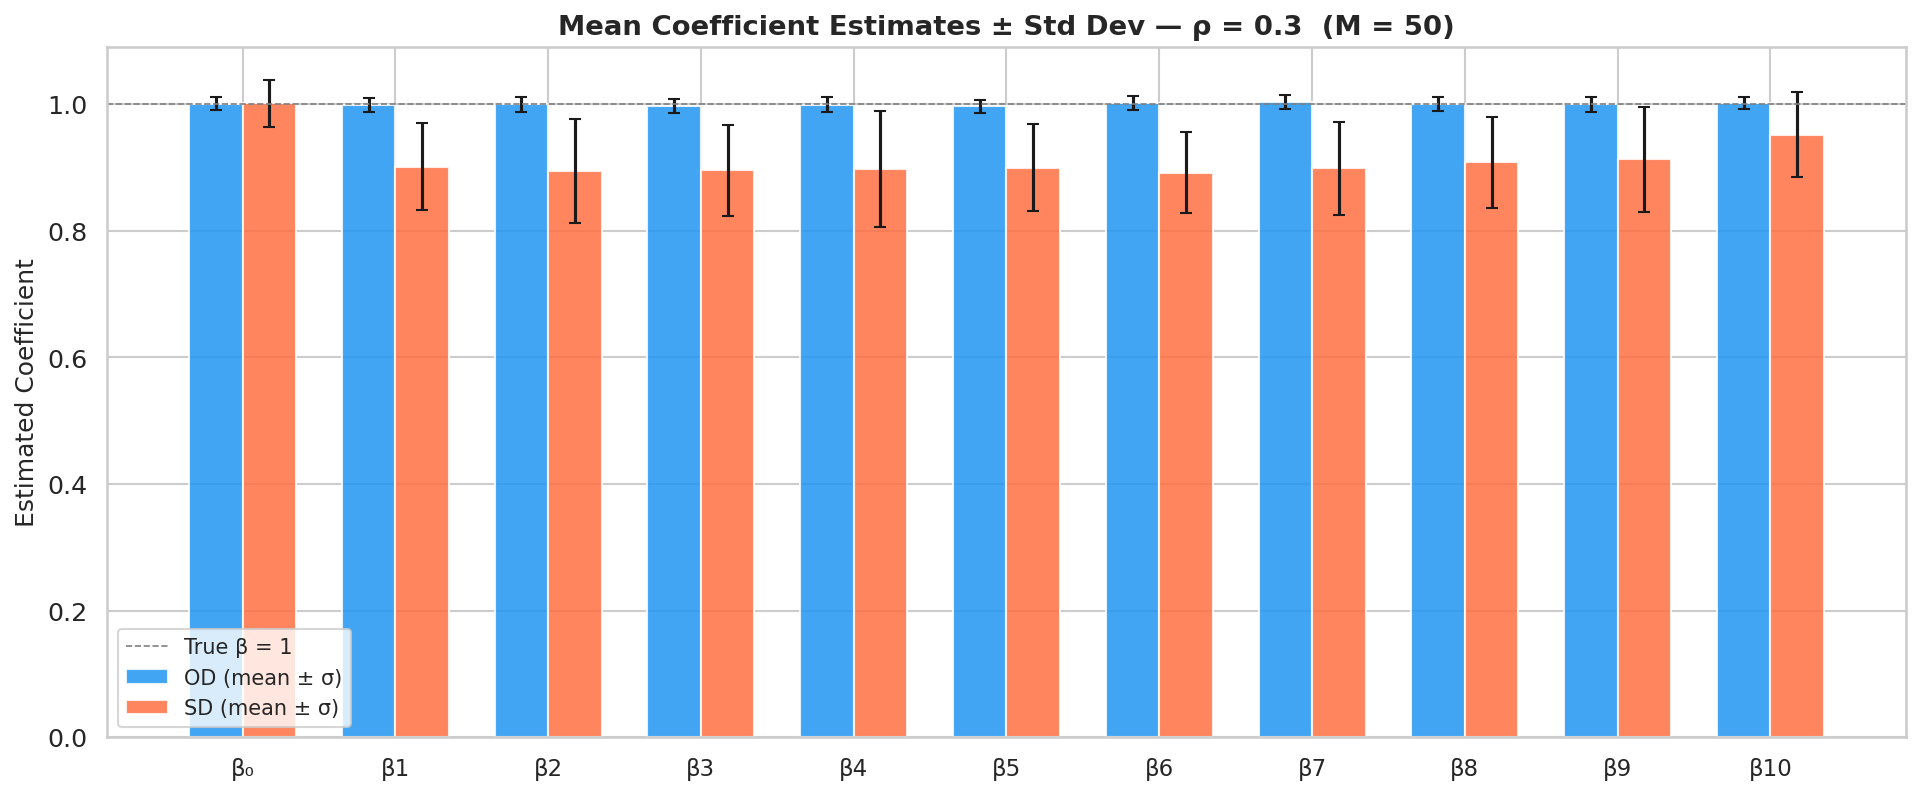

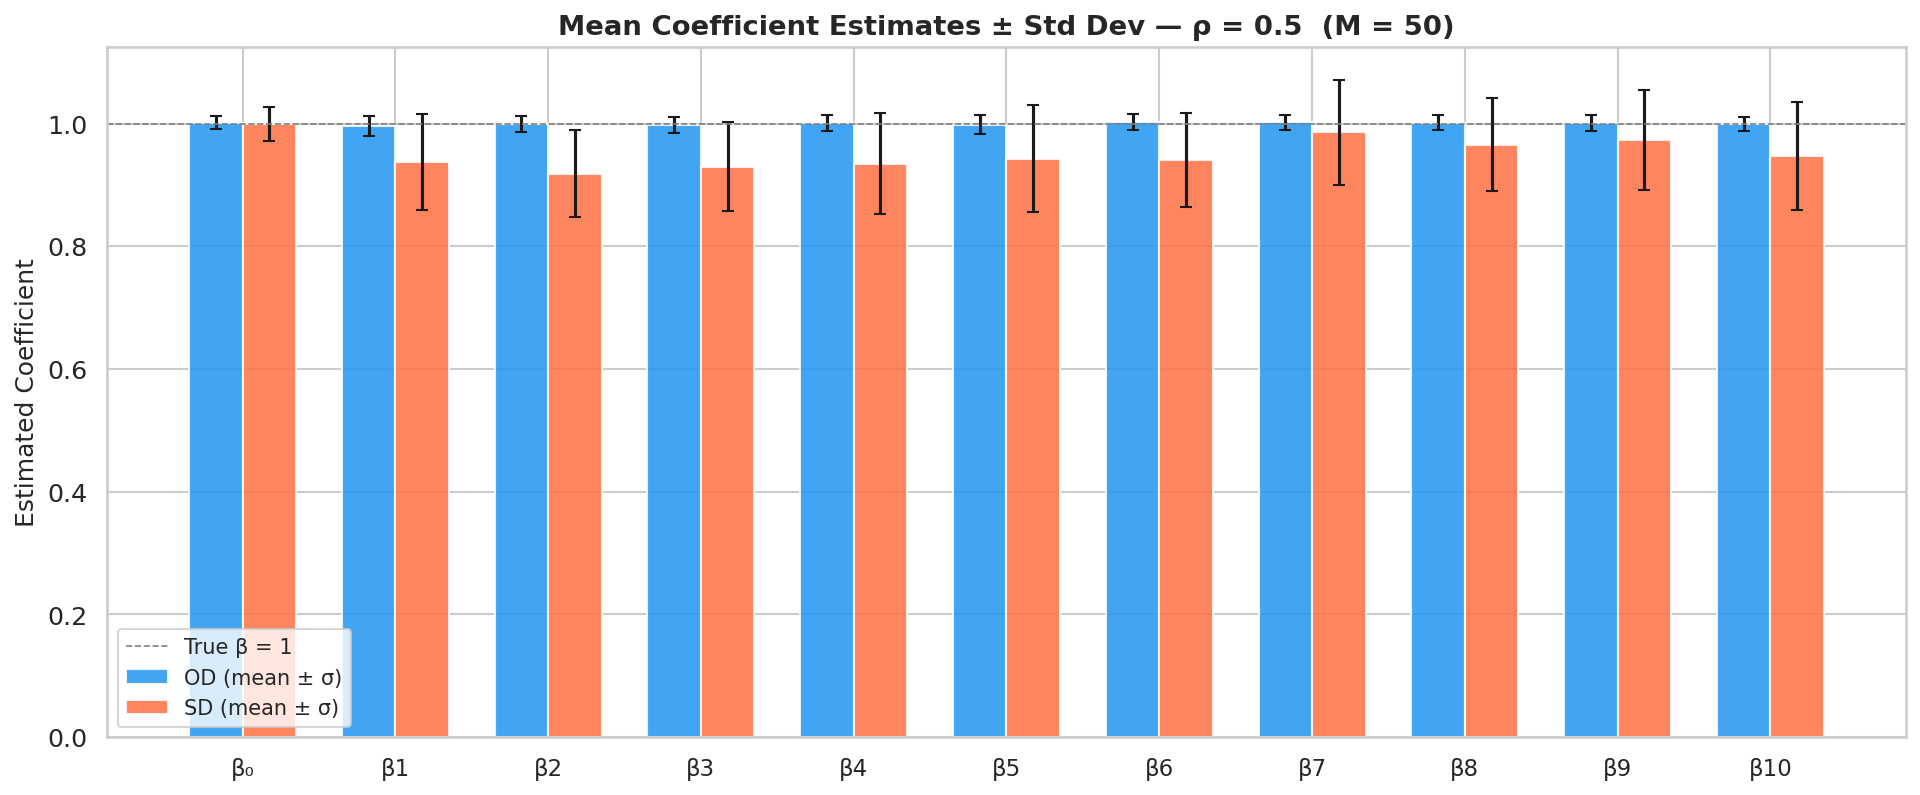

In [8]:
# ── Plot 2: Coefficient comparison — Mean ± CI per scenario ─────────────────
terms = ["β₀"] + [f"β{i+1}" for i in range(p)]
palette_rho = sns.color_palette("Set2", len(rho_vals))

for mf in model_files:
    with open(mf, "rb") as f:
        bundle = pickle.load(f)

# Aggregate coefficient estimates across reps
coef_rows = []
for mf in model_files:
    with open(mf, "rb") as f:
        bundle = pickle.load(f)
    lm_od = bundle["lm_od"]
    lm_sd = bundle["lm_sd"]
    rho   = bundle.get("rho", float(re.search(r"rho([\d.]+)", bundle["scenario"]).group(1)))
    rep   = bundle.get("rep", 1)
    beta_od = np.concatenate([[lm_od.intercept_], lm_od.coef_])
    beta_sd = np.concatenate([[lm_sd.intercept_], lm_sd.coef_])
    for j, name in enumerate(terms):
        coef_rows.append({
            "rho": rho, "rep": rep, "term": name,
            "beta_od": beta_od[j], "beta_sd": beta_sd[j],
        })

coef_df = pd.DataFrame(coef_rows)

for rho_val in sorted(metrics_df["rho"].unique()):
    sub = coef_df[coef_df["rho"] == rho_val]

    od_stats = sub.groupby("term")["beta_od"].agg(["mean", "std"]).reindex(terms)
    sd_stats = sub.groupby("term")["beta_sd"].agg(["mean", "std"]).reindex(terms)

    x_pos = np.arange(len(terms))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 5.5))

    ax.bar(x_pos - width/2, od_stats["mean"], width,
           yerr=od_stats["std"], capsize=3,
           label="OD (mean ± σ)", color="#2196F3", edgecolor="white", alpha=0.85)
    ax.bar(x_pos + width/2, sd_stats["mean"], width,
           yerr=sd_stats["std"], capsize=3,
           label="SD (mean ± σ)", color="#FF7043", edgecolor="white", alpha=0.85)

    ax.axhline(y=1.0, color="grey", ls="--", lw=0.8, label="True β = 1")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(terms, fontsize=11)
    ax.set_ylabel("Estimated Coefficient")
    ax.set_title(f"Mean Coefficient Estimates ± Std Dev — ρ = {rho_val}  (M = {M})")
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"plot_coef_mean_rho{rho_val}.png"), dpi=200, bbox_inches="tight")
    plt.show()

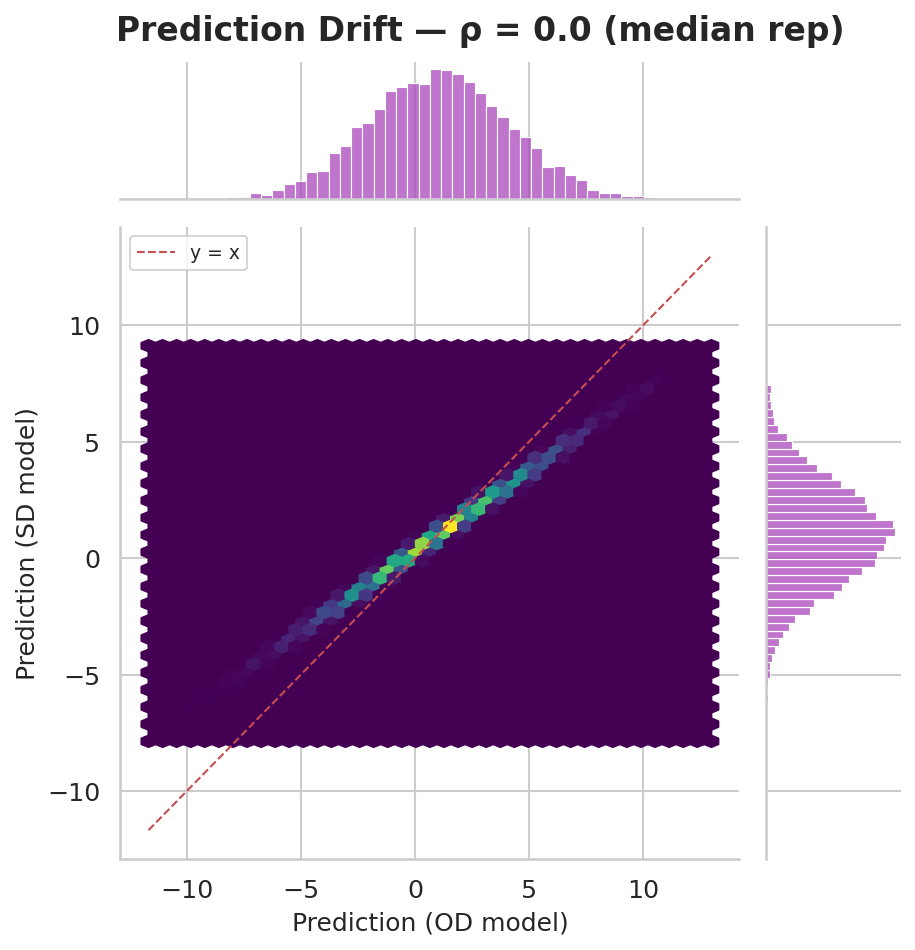

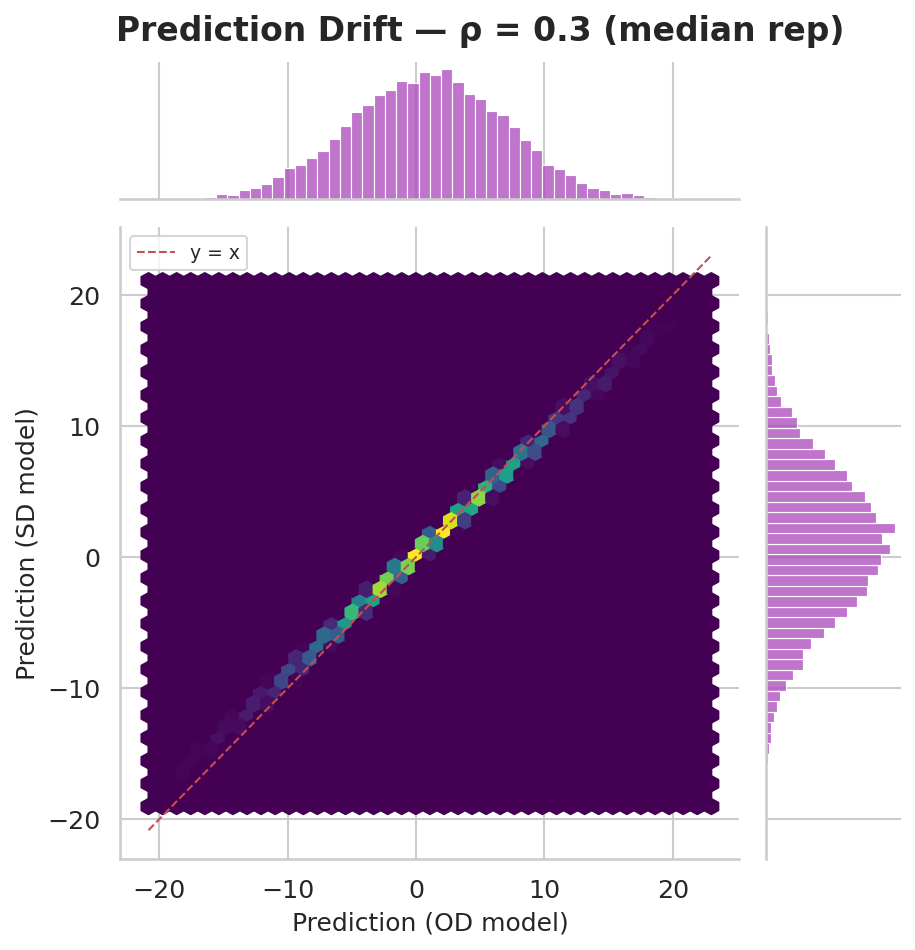

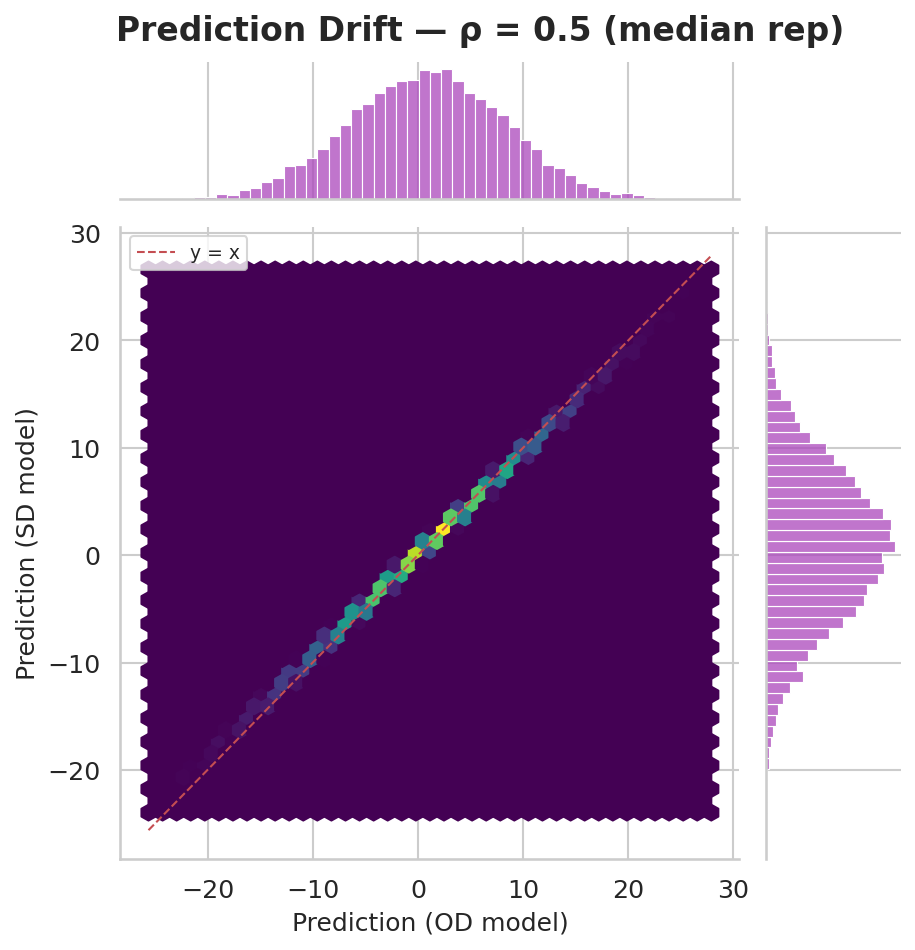

In [9]:
# ── Plot 3: Prediction Drift — OD vs SD predictions on test set ─────────────
# For each rho, pick one representative rep and show scatter + marginals

for rho_val in sorted(metrics_df["rho"].unique()):
    # Pick the rep closest to the median Eucl. distance for that rho
    sub = metrics_df[metrics_df["rho"] == rho_val]
    median_dist = sub["euclidean_dist"].median()
    best_rep_idx = (sub["euclidean_dist"] - median_dist).abs().idxmin()
    best_scenario = sub.loc[best_rep_idx, "scenario"]

    mf = os.path.join(model_dir, f"models_{best_scenario}.pkl")
    with open(mf, "rb") as f:
        bundle = pickle.load(f)

    lm_od = bundle["lm_od"]
    lm_sd = bundle["lm_sd"]

    test_data = test_sets[rho_val]
    X_test = test_data.drop(columns="y")

    pred_od = lm_od.predict(X_test)
    pred_sd = lm_sd.predict(X_test)

    g = sns.jointplot(
        x=pred_od, y=pred_sd, kind="hex",
        height=6, ratio=4,
        marginal_kws=dict(bins=50, color="#AB47BC"),
        joint_kws=dict(gridsize=40, cmap="viridis"),
    )
    lims = [min(pred_od.min(), pred_sd.min()), max(pred_od.max(), pred_sd.max())]
    g.ax_joint.plot(lims, lims, "r--", lw=1, label="y = x")
    g.ax_joint.set_xlabel("Prediction (OD model)")
    g.ax_joint.set_ylabel("Prediction (SD model)")
    g.ax_joint.legend(fontsize=9)
    g.figure.suptitle(
        f"Prediction Drift — ρ = {rho_val} (median rep)", fontweight="bold", y=1.02
    )
    g.savefig(os.path.join(result_dir, f"plot_pred_drift_rho{rho_val}.png"), dpi=200, bbox_inches="tight")
    plt.show()

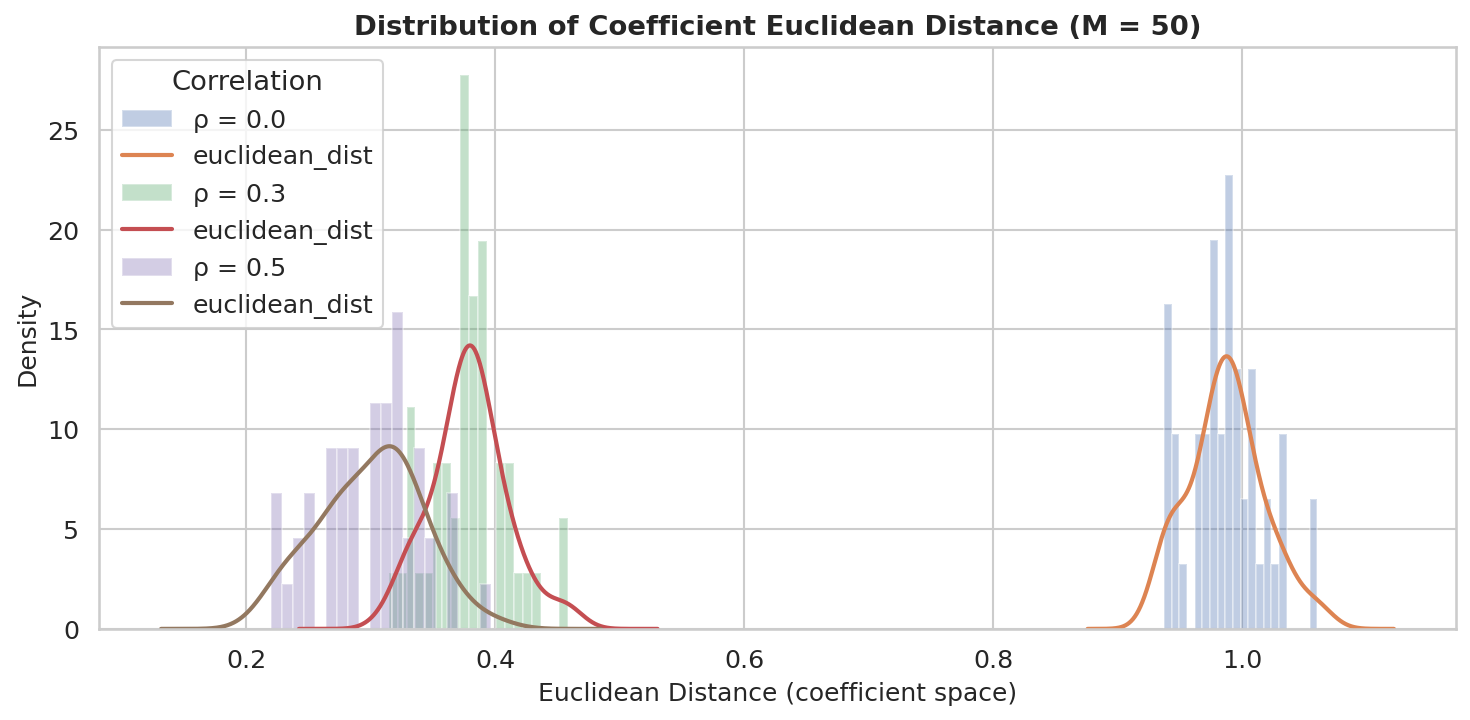

In [10]:
# ── Plot 4: Euclidean Distance — Histogram + KDE per ρ ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for rho_val in sorted(metrics_df["rho"].unique()):
    sub = metrics_df[metrics_df["rho"] == rho_val]["euclidean_dist"]
    ax.hist(sub, bins=20, alpha=0.35, label=f"ρ = {rho_val}", density=True)
    sub.plot.kde(ax=ax, linewidth=2)

ax.set_xlabel("Euclidean Distance (coefficient space)")
ax.set_ylabel("Density")
ax.set_title(f"Distribution of Coefficient Euclidean Distance (M = {M})")
ax.legend(title="Correlation")

plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_eucl_dist_hist.png"), dpi=200, bbox_inches="tight")
plt.show()

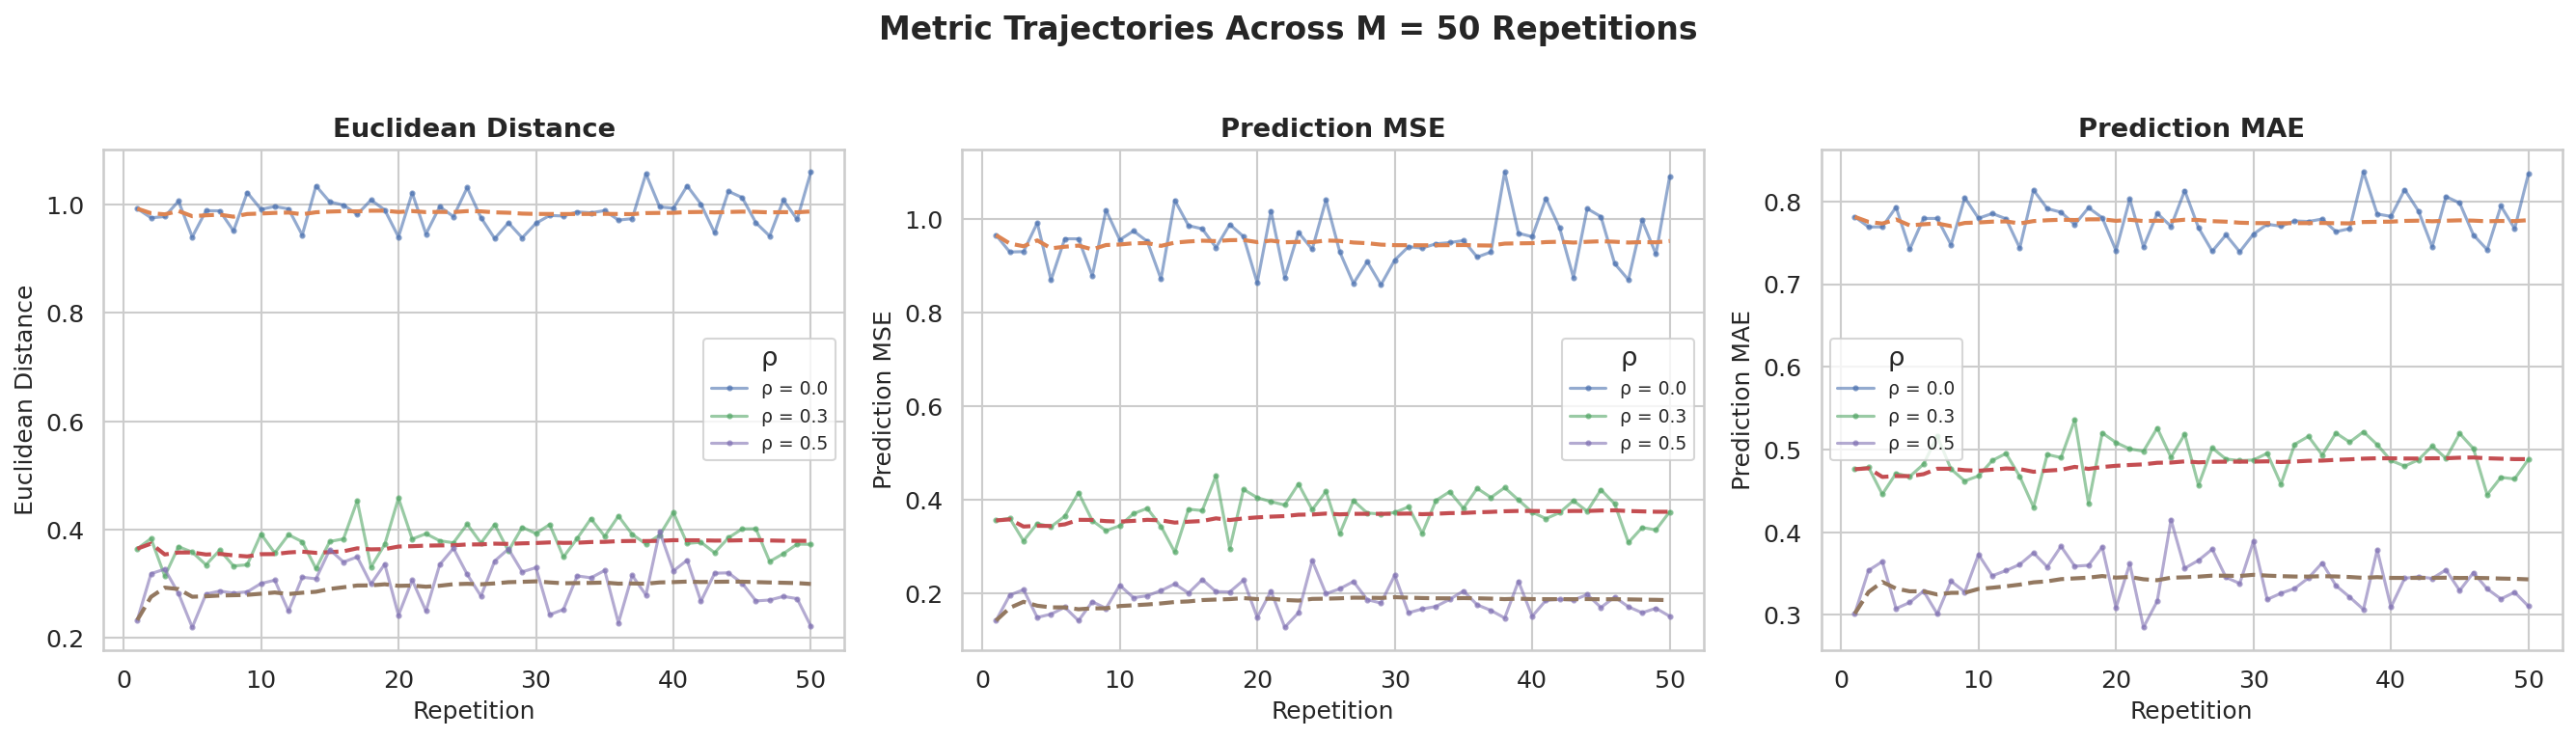

In [11]:
# ── Plot 5: Metrics Across Repetitions — Line Plot with CI ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_list = [
    ("euclidean_dist",  "Euclidean Distance", axes[0]),
    ("prediction_mse",  "Prediction MSE",     axes[1]),
    ("prediction_mae",  "Prediction MAE",     axes[2]),
]

for col, title, ax in metric_list:
    for rho_val in sorted(metrics_df["rho"].unique()):
        sub = metrics_df[metrics_df["rho"] == rho_val].sort_values("rep")
        ax.plot(sub["rep"], sub[col], alpha=0.6, marker=".", markersize=4,
                label=f"ρ = {rho_val}")
        # Running mean
        running = sub[col].expanding().mean()
        ax.plot(sub["rep"], running, lw=2, ls="--")

    ax.set_xlabel("Repetition")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=9, title="ρ")

plt.suptitle(f"Metric Trajectories Across M = {M} Repetitions", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_metrics_trajectory.png"), dpi=200, bbox_inches="tight")
plt.show()

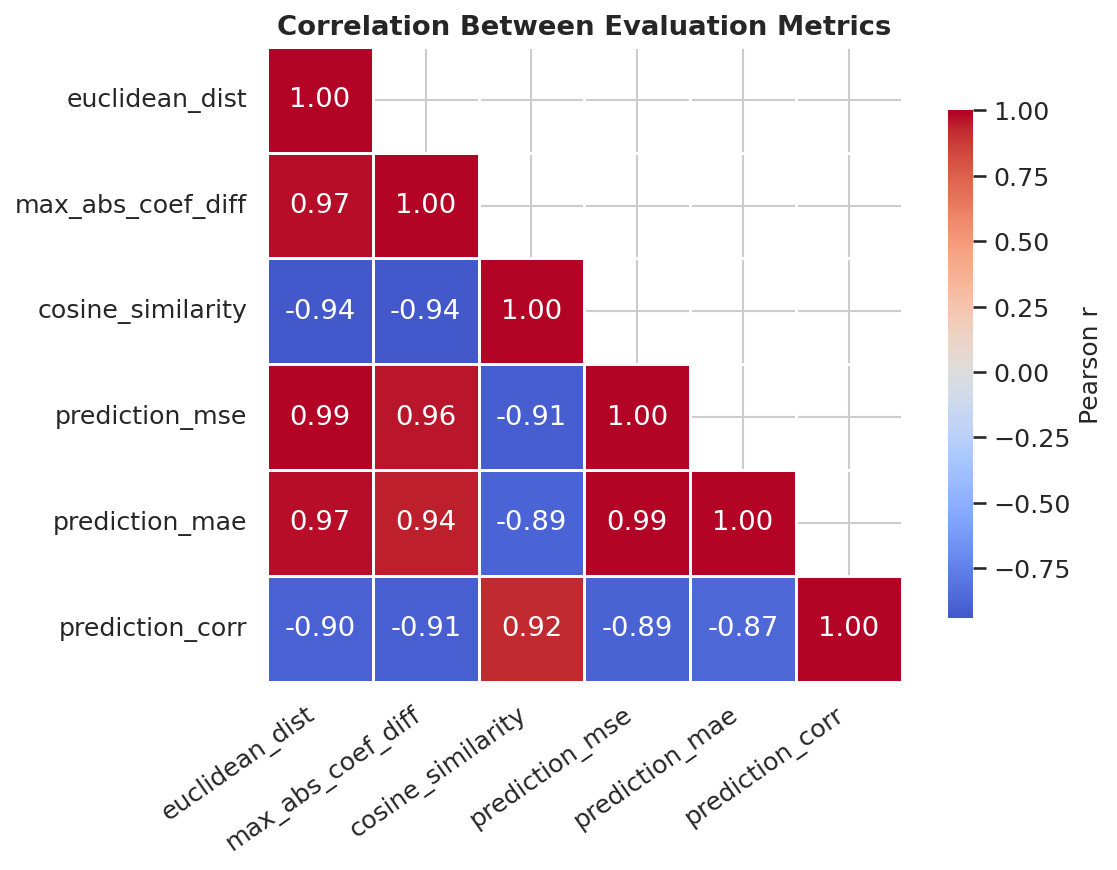

In [12]:
# ── Plot 6: Pairwise Metric Correlation Heatmap ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = metrics_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Correlation Between Evaluation Metrics")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_metric_correlation.png"), dpi=200, bbox_inches="tight")
plt.show()

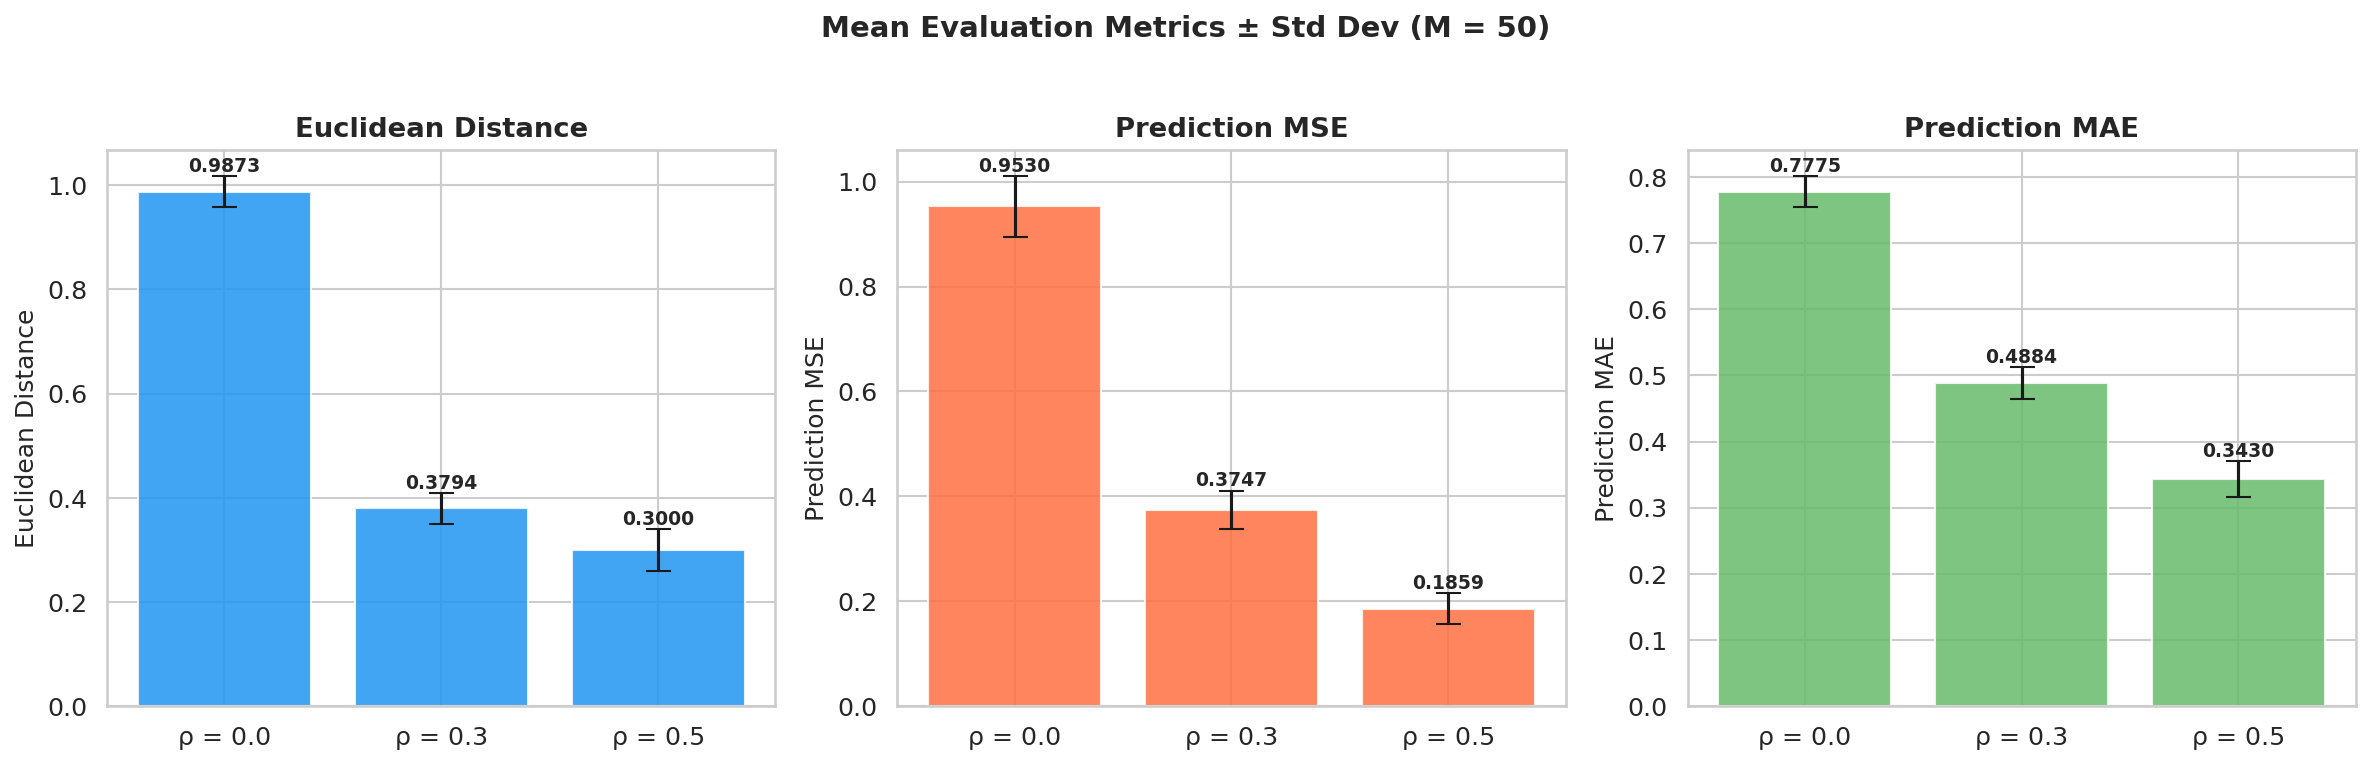


[DONE] Evaluation complete. All plots saved to ../results/


In [13]:
# ── Plot 7: Summary Bar Chart — Mean Metrics with Error Bars ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#2196F3", "#FF7043", "#66BB6A"]
rho_labels = [f"ρ = {r}" for r in sorted(metrics_df["rho"].unique())]

for ax, (col, title), color in zip(
    axes,
    [("euclidean_dist", "Euclidean Distance"),
     ("prediction_mse", "Prediction MSE"),
     ("prediction_mae", "Prediction MAE")],
    colors,
):
    grouped = metrics_df.groupby("rho")[col]
    means = grouped.mean()
    stds  = grouped.std()

    bars = ax.bar(
        rho_labels, means, yerr=stds,
        color=color, edgecolor="white", capsize=6, alpha=0.85,
    )
    # Value labels on bars
    for bar, m, s in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.001,
            f"{m:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold",
        )
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_xlabel("")

plt.suptitle(f"Mean Evaluation Metrics ± Std Dev (M = {M})", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_evaluation_metrics.png"), dpi=200, bbox_inches="tight")
plt.show()

print("\n[DONE] Evaluation complete. All plots saved to ../results/")